# Why churning concepts spread: HOME partner classes and the Exp11 closure test (demo)

This notebook demos **Experiment 15** of the *"concepts spread once adopters make them"* study. The study uses OpenAlex legacy concepts: a concept's **home** fields are the fields where it first appears, and its later **breadth** `O2r_m50` is the rarefied number of venue fields it reaches at m = 50 papers, 6-8 years after onset. Every association is a **partial Spearman** (psp) given the **B5 baseline**: early volume, growth, off-home share, field entropy and reach.

The experiment has three parts. This demo runs the two that the paper cites:

* **Part A: HOME partner-class decomposition (EXPLORATORY).** The HOME novelty/churn score `NOVCHURN_home` is the mean of z(`NOV_res`) and -z(`edge_persistence`), using constants frozen on EXP5. It predicts later breadth. *Why?* Each concept's early HOME-only partners (co-occurring concepts) are classified on four axes: METHOD vs DOMAIN type, **new vs old backbone community**, low vs high degree, and **mixed vs pure-home carrier papers**. The totals (`NOV_res`, `new_edge_rate`, `churn`) are split **exactly** into class parts. Each part is scored by psp given B5 (plus t0, group and body dummies), with Holm-corrected contrasts C1-C5 and exact Shapley attribution. The paper's claim: *"the home-only signal is carried by partners from new Leiden communities arriving through mixed-field papers: C2 = +0.102 [+0.069, +0.133] (Holm p = 0.0025) ... Controlling for the share of early bridging papers halves NOVCHURN from 0.118 to 0.056."*
* **Part C: completion of the sealed Exp11 within-concept closure test.** Does a concept's HOME ego-network *closing* (density up, OPEN_home down) precede *fewer* off-home field entries the next year *within the same concept*? The test is a PPML regression of `entries(t+1)` on `density(t)` or `OPEN_home(t)` plus size controls, with **concept + year fixed effects** and CRV1 clustered by concept. The paper's claim: *"A within-concept closure test is null on DEV (density b = -0.070 [-0.180, 0.040]; OPEN_home b = +0.015 [-0.038, 0.069]). On held-out fields, OPEN_home is opposite-signed (-0.079 [-0.146, -0.013])."*

**What the original `method.py` is.** It is an orchestrator that runs about 13 stages in order: the sealed Exp11 copy and seal check, FE body models, the event study, sequence tests, the HOME partner build from a 12,499-concept OpenAlex frame, the hash seal, unit tests, Part A scoring and Part B trait stability. It then assembles `exp11_completion.json` and `method_out.json`. Those stages need the run's cached OpenAlex frames (tens of GB) and hours of CPU, so the demo **cannot** rerun the builds. Instead it takes the artifact's own final feature tables and runs the artifact's **scoring code**, nearly verbatim, on stratified subsets:

1. **Part A:** `lib_iter5/partA_stats.py` (Scorer, Shapley) and `score_partA.run_task` on **2,000 of the 7,203** pooled EXP5 concepts.
2. **Part C:** `exp11_code/lib/fe_stats.ppml` and `analysis_fe.ppml_x` (pyfixest `fepois`) on the yearly panel of **1,000 DEV** and **1,000 OLD_HELDOUT** concepts.

Subsets have wider CIs than the full data. The final cell compares every number with the full-data result stored in the artifact.

## Setup
`pyfixest` is not pre-installed on Colab, so it is always installed. The scientific core is pre-installed on Colab and is installed locally only, at Colab's exact versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# pyfixest -- NOT on Colab, always install (the original Exp11 PPML estimator: pyfixest.fepois)
_pip('pyfixest==0.60.0')

# Core packages -- pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
These are the original import blocks of `score_partA.py`, `lib_iter5/partA_stats.py`, `exp11_code/lib/rq1stats.py` and `exp11_code/lib/fe_stats.py`, merged. The multiprocessing, argparse and loguru imports are not needed, because the demo runs one task in-process. `matplotlib` is used for the final figure.

In [2]:
from __future__ import annotations

import itertools
import json
import math
import time
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## Data loading
`mini_demo_data.json` is column-oriented. It holds:
- `partA_concepts`: 2,000 EXP5 concepts, stratified by body × group, with every column that `score_partA.run_task` reads;
- `partC_panel`: the Exp11 yearly estimation panel for 1,000 DEV and 1,000 OLD_HELDOUT concepts;
- `novchurn_constants`: the frozen NOVCHURN constants;
- `reference_results`: the full-data results for comparison.

The file loads from GitHub, with a local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-5/experiment-15/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
D5 = pd.DataFrame(data["partA_concepts"]).astype({c: float for c in ["O2r_m50", "O2r_resid"]})
PANEL = pd.DataFrame(data["partC_panel"])
for c in D5.columns:
    if D5[c].dtype == object and c not in ("group", "unit", "body"):
        D5[c] = pd.to_numeric(D5[c])
for c in ("density", "OPEN_home", "log1p_home", "log1p_all", "log1p_deg", "log_at_risk", "y_next"):
    PANEL[c] = PANEL[c].astype(float)
REF = data["reference_results"]
print(data["description"])
print(f"\nPart A: {len(D5)} concepts x {D5.shape[1]} columns; bodies {D5.body.value_counts().to_dict()}")
print(f"Part C: {len(PANEL)} concept-years; "
      f"{PANEL.groupby('body').ci.nunique().to_dict()} concepts per body")

Mini demo data for Exp15 (iteration 5): Part A = HOME partner-class decomposition of the NOVCHURN_home signal (EXPLORATORY), Part C = completion of the sealed Exp11 within-concept closure test (PPML, concept + year FE). Concept subsets are stratified; full-data results are in reference_results.

Part A: 2000 concepts x 102 columns; bodies {'DEV': 885, 'COHORT_2010_14': 606, 'OLD_HELDOUT': 509}
Part C: 13719 concept-years; {'DEV': 1000, 'OLD_HELDOUT': 1000} concepts per body


## Config
In the original, these values come from `results/frozen_spec_iter5.json` (`seed`, `N_BOOT` = 2,000 concept bootstraps) and from `common_iter5.py` (`B5`). On 2,000 concepts the scorer evaluates about 160 columns per resample. On the 2,000-concept subset, the original **2,000** draws take about 90 s. Lower `N_BOOT` (for example to 300) for a quicker run.

In [5]:
SEED = data["seed"]                 # 20260929 (common_iter5.SEED)
B5 = data["B5"]                     # ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
N_BOOT = 2000                       # = spec["N_BOOT"] (original); lower for a quicker run
k = data["novchurn_constants"]      # frozen: spec["novchurn_constants"] (Exp10 open_constants.home)
CONTROLS = ["log1p_home", "log1p_all", "log1p_deg", "log_at_risk"]   # exp11_code/lib/panel_m.CONTROLS
print(json.dumps(k, indent=1))

{
 "source": "Exp10 results/frozen_spec.json open_constants.home",
 "NOV_res": {
  "lo": -0.9844771539499432,
  "hi": 0.09593876134862721,
  "mu": -0.540875353868789,
  "sd": 0.3801298233025086,
  "sign": 1,
  "n": 9475
 },
 "edge_persistence": {
  "lo": 0.0,
  "hi": 0.6739705882352984,
  "mu": 0.12122673391085216,
  "sd": 0.15763666320353067,
  "sign": -1,
  "n": 11236
 }
}


## Part A, step 1: the statistics library
`exp11_code/lib/rq1stats.py` supplies `dummies`, `dersimonian_laird` and `holm`. `lib_iter5/partA_stats.py` is a vectorised partial Spearman that reproduces EXP8's `psp_point` column by column, with shared bootstrap indices, plus the exact Shapley value. Both are verbatim.

In [6]:
# ---------------------------------------------------------------- exp11_code/lib/rq1stats.py (verbatim excerpts)
def dummies(v: np.ndarray, drop_first: bool = True) -> np.ndarray:
    u = np.unique(v)
    if len(u) <= 1:
        return np.zeros((len(v), 0))
    cols = u[1:] if drop_first else u
    return (v[:, None] == cols[None, :]).astype(float)


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()


# ---------------------------------------------------------------- lib_iter5/partA_stats.py (verbatim)
def _psp_block(X: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> np.ndarray:
    Zc = [np.ones((len(y), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    Y = np.c_[rankdata(X, axis=0), rankdata(y)]
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    R = Y - Z @ beta
    Rx, Ry = R[:, :-1], R[:, -1]
    sx, sy = Rx.std(0), Ry.std()
    Rxc, Ryc = Rx - Rx.mean(0), Ry - Ry.mean()
    with np.errstate(invalid="ignore", divide="ignore"):
        r = (Rxc * Ryc[:, None]).mean(0) / (sx * sy)
    r[(sx <= 1e-12) | (sy <= 1e-12)] = np.nan
    # a constant column has rank residuals that are pure lstsq round-off (ranks ~ n/2): psp undefined
    r[np.ptp(X, axis=0) == 0] = np.nan
    if np.ptp(y) == 0:
        r[:] = np.nan
    return r


class Scorer:
    # All columns of X against one outcome y given B (+cat), point and bootstrap, shared resample indices.

    def __init__(self, X: np.ndarray, names: list[str], y: np.ndarray, B: np.ndarray, cat: np.ndarray | None,
                 min_n: int = 30):
        self.names = list(names)
        base = np.isfinite(y) & np.all(np.isfinite(B), 1)
        if cat is not None and cat.shape[1]:
            base &= np.all(np.isfinite(cat), 1)
        self.base_idx = np.nonzero(base)[0]
        self.X, self.y, self.B, self.cat = X, y, B, cat
        fin = np.isfinite(X) & base[:, None]
        groups: dict[bytes, list[int]] = {}
        for j in range(X.shape[1]):
            groups.setdefault(np.packbits(fin[:, j]).tobytes(), []).append(j)
        self.groups = [(fin[:, cols[0]], np.array(cols)) for cols in groups.values()]
        self.min_n = min_n
        self.n = {names[j]: int(fin[:, j].sum()) for j in range(X.shape[1])}

    def eval(self, idx: np.ndarray | None = None) -> np.ndarray:
        # psp of every column on the rows idx (a resample of base_idx; None = the observed sample).
        idx = self.base_idx if idx is None else idx
        out = np.full(self.X.shape[1], np.nan)
        for m, cols in self.groups:
            j = idx[m[idx]]
            if len(j) < self.min_n:
                continue
            Xj = self.X[np.ix_(j, cols)]
            cat = self.cat[j] if self.cat is not None and self.cat.shape[1] else None
            out[cols] = _psp_block(Xj, self.y[j], self.B[j], cat)
        return out

    def boot(self, n_boot: int, seed: int) -> np.ndarray:
        rng = np.random.default_rng(seed)
        nb = len(self.base_idx)
        return np.vstack([self.eval(self.base_idx[rng.integers(0, nb, nb)]) for _ in range(n_boot)])


def summarize(point: float, bs: np.ndarray) -> dict:
    v = bs[np.isfinite(bs)]
    if not np.isfinite(point) or len(v) < 10:
        return {"rho": point if np.isfinite(point) else None, "ci": None, "se": None, "z": None, "se_z": None,
                "p_two": None, "n_boot_ok": int(len(v))}
    z = np.arctanh(np.clip(v, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1))
    ze = math.atanh(max(min(point, 0.999999), -0.999999))
    return {"rho": float(point), "ci": [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))],
            "se": float(np.std(v, ddof=1)), "z": ze, "se_z": se_z,
            "p_two": float(min(1.0, 2 * min((v <= 0).mean(), (v >= 0).mean()) + 1 / len(v))),
            "n_boot_ok": int(len(v))}


def summarize_diff(pa: float, pb: float, ba: np.ndarray, bb: np.ndarray) -> dict:
    d = ba - bb
    d = d[np.isfinite(d)]
    est = pa - pb
    if not np.isfinite(est) or len(d) < 10:
        return {"diff": est if np.isfinite(est) else None, "ci": None, "se": None, "p_two": None}
    return {"diff": float(est), "ci": [float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))],
            "se": float(np.std(d, ddof=1)),
            "p_two": float(min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()) + 1 / len(d))), "n_boot_ok": int(len(d))}


def subsets(players: list[str]) -> list[frozenset]:
    return [frozenset(c) for r in range(len(players) + 1) for c in itertools.combinations(players, r)]


def shapley(players: list[str], v: dict[frozenset, float]) -> dict[str, float]:
    # Exact Shapley value: phi_i = sum_S |S|!(n-|S|-1)!/n! (v(S+i) - v(S)).
    n = len(players)
    phi = {}
    for p in players:
        others = [q for q in players if q != p]
        s = 0.0
        for r in range(n):
            w = math.factorial(r) * math.factorial(n - r - 1) / math.factorial(n)
            for c in itertools.combinations(others, r):
                S = frozenset(c)
                s += w * (v[S | {p}] - v[S])
        phi[p] = s
    return phi

## Part A, step 2: the scoring code of `score_partA.py`
The class axes, the five pre-declared Holm contrasts, `novchurn`, `component_columns`, the Shapley `games`, `design`, `run_task` and `psp_extra` are verbatim. The changes are:
- the in-function `from partA_stats / rq1stats import ...` lines are dropped, because those functions are defined above;
- `design` loses its Exp10-ladder branch (`rung`), which only the 2015-17 cohort bodies use.

In [7]:
AXES = {"type": ["METHOD", "DOMAIN", "OTHER"], "comm": ["new", "old", "unk"], "deg": ["low", "high"],
        "carrier": ["mixed", "pure"]}
NOV_AXES = ["type", "deg", "carrier"]
PAIRS = {"type": ("METHOD", "DOMAIN"), "comm": ("new", "old"), "deg": ("low", "high"), "carrier": ("mixed", "pure")}
TC = [("METHOD", "new"), ("METHOD", "old"), ("DOMAIN", "new"), ("DOMAIN", "old")]
HOLM = {"C1_METHOD_minus_DOMAIN_novnull": ("novnull_type_METHOD", "novnull_type_DOMAIN"),
        "C2_commnew_minus_commold_ner": ("ner_comm_new", "ner_comm_old"),
        "C3_lowdeg_minus_highdeg_nov": ("nov_deg_low", "nov_deg_high"),
        "C4_mixed_minus_pure_ner": ("ner_carrier_mixed", "ner_carrier_pure"),
        "C5_dropped_minus_added_churn": ("chd_all", "cha_all")}


def novchurn(nov: np.ndarray, ep: np.ndarray, n_home: np.ndarray, k: dict) -> np.ndarray:
    a, b = k["NOV_res"], k["edge_persistence"]
    zn = a["sign"] * (np.clip(nov, a["lo"], a["hi"]) - a["mu"]) / a["sd"]
    ze = b["sign"] * (np.clip(ep, b["lo"], b["hi"]) - b["mu"]) / b["sd"]
    out = (zn + ze) / 2
    out[~(np.isfinite(zn) & np.isfinite(ze)) | (n_home < 10)] = np.nan
    return out


def component_columns(F: pd.DataFrame) -> list[str]:
    cols = ["NOV_res", "new_edge_rate", "churn", "edge_persistence", "NOVCHURN_home", "OPEN_home",
            "bridging_share_home", "chd_all", "cha_all", "M", "n1"]
    for ax, cl in AXES.items():
        for X in cl:
            if F[f"m_{ax}_{X}"].sum() == 0:
                continue
            cols += [f"ner_{ax}_{X}", f"ch_{ax}_{X}", f"chd_{ax}_{X}", f"cha_{ax}_{X}"]
            if ax in NOV_AXES:
                cols += [f"nov_{ax}_{X}", f"novnull_{ax}_{X}"]
    cols += [f"jner_{t}_{c}" for t, c in TC] + [f"jch_{t}_{c}" for t, c in TC]
    if "new_edge_rate_ALL" in F:
        cols.append("new_edge_rate_ALL")
    return [c for c in cols if c in F.columns]


def games(F: pd.DataFrame, k: dict) -> dict:
    # {game: (players, target_fn(S) -> column values, fair share dict)} built on the body's rows.
    G = {}
    nh = F.n_home_early.to_numpy(float)
    ok_nc = np.isfinite(F.NOVCHURN_home.to_numpy(float))
    for ax in NOV_AXES:
        pl = [X for X in AXES[ax] if F[f"m_{ax}_{X}"].sum() > 0]
        nov = {X: F[f"nov_{ax}_{X}"].to_numpy(float) for X in pl}
        ch = {X: F[f"ch_{ax}_{X}"].to_numpy(float) for X in pl}
        mn = {X: np.nanmean(nov[X][ok_nc]) for X in pl}
        mc = {X: np.nanmean(ch[X][ok_nc]) for X in pl}
        cols = {}
        for S in subsets(pl):
            nv = sum(nov[X] if X in S else mn[X] for X in pl)
            cv = sum(ch[X] if X in S else mc[X] for X in pl)
            t = novchurn(np.asarray(nv, float) + 0 * F.NOV_res.to_numpy(float), 1 - np.asarray(cv, float), nh, k)
            t[~ok_nc] = np.nan
            cols[S] = t
        M = F.M.to_numpy(float)
        share_new = {X: float(F.loc[ok_nc, f"m_{ax}_{X}"].sum() / max(M[ok_nc].sum(), 1)) for X in pl}
        share_ch = {X: float(np.nanmean(ch[X][ok_nc]) / np.nanmean(F.churn.to_numpy(float)[ok_nc])) for X in pl}
        G[f"NOVCHURN_{ax}"] = (pl, cols, {"new_partner_share": share_new, "churn_mass_share": share_ch})
    # direction game
    parts = {"NOV": F.NOV_res.to_numpy(float), "DROP": F.chd_all.to_numpy(float), "ADD": F.cha_all.to_numpy(float)}
    mp_ = {p: np.nanmean(v[ok_nc]) for p, v in parts.items()}
    cols = {}
    for S in subsets(list(parts)):
        nv = parts["NOV"] if "NOV" in S else mp_["NOV"] + 0 * parts["NOV"]
        cv = sum(parts[p] if p in S else mp_[p] for p in ("DROP", "ADD"))
        t = novchurn(np.asarray(nv, float), 1 - np.asarray(cv, float), nh, k)
        t[~ok_nc] = np.nan
        cols[S] = t
    tot = np.nanmean(F.churn.to_numpy(float)[ok_nc])
    G["NOVCHURN_direction"] = (list(parts), cols, {"churn_mass_share": {
        "DROP": float(np.nanmean(parts["DROP"][ok_nc]) / tot), "ADD": float(np.nanmean(parts["ADD"][ok_nc]) / tot)}})
    # type x community games on new_edge_rate and churn
    for nm, pre, rest in (("ner_type_x_comm", "jner", "jner_rest"), ("churn_type_x_comm", "jch", "jch_rest")):
        pl = [f"{t}_{c}" for t, c in TC]
        v = {p: F[f"{pre}_{p}"].to_numpy(float) for p in pl}
        rv = F[rest].to_numpy(float)
        ok = np.isfinite(rv)
        mv = {p: np.nanmean(v[p][ok]) for p in pl}
        cols = {}
        for S in subsets(pl):
            t = rv + sum(v[p] if p in S else mv[p] for p in pl)
            t = np.asarray(t, float)
            t[~ok] = np.nan
            cols[S] = t
        share = {p: float(np.nanmean(v[p][ok]) / np.nanmean((rv + sum(v.values()))[ok])) for p in pl}
        G[nm] = (pl, cols, {"mass_share": share})
    return G


def design(d: pd.DataFrame, body: str, rung: str | None) -> tuple[np.ndarray, np.ndarray]:
    # (the Exp10-ladder branch `if rung is not None: ...` is used only by the 2015-17 cohort bodies -> omitted)
    parts = [dummies(d.t0.to_numpy())]
    if body in ("DEV", "OLD_HELDOUT", "COHORT_2010_14", "POOLED_EXP5"):
        parts.append(dummies(d.group.to_numpy()))
    if body == "POOLED_EXP5":
        parts.append(dummies(d.body.to_numpy()))
    return d[B5].to_numpy(float), np.hstack(parts)


def run_task(args) -> dict:
    body, rung, outcome, d, cols, k, n_boot, seed, with_games = args
    t = time.time()
    B, cat = design(d, body, rung)
    y = d[outcome].to_numpy(float)
    G = games(d, k) if with_games else {}
    gcols, gnames = [], []
    for g, (pl, cmap, _) in G.items():
        for S, v in cmap.items():
            gcols.append(v)
            gnames.append((g, S))
    X = np.column_stack([d[c].to_numpy(float) for c in cols] + gcols)
    names = cols + [f"G::{g}::{'|'.join(sorted(S))}" for g, S in gnames]
    sc = Scorer(X, names, y, B, cat)
    pt = sc.eval()
    bs = sc.boot(n_boot, seed)
    ix = {n: i for i, n in enumerate(names)}
    res = {"body": body, "rung": rung, "outcome": outcome, "n_base": int(len(sc.base_idx)), "n_boot": n_boot,
           "components": {}, "diffs": {}, "holm_contrasts": {}, "shapley": {}}
    for c in cols:
        res["components"][c] = {**summarize(pt[ix[c]], bs[:, ix[c]]), "n": sc.n[c]}
    for ax, (a, b) in PAIRS.items():
        for pre in ("ner", "ch", "chd", "cha") + (("nov", "novnull") if ax in NOV_AXES else ()):
            ca, cb = f"{pre}_{ax}_{a}", f"{pre}_{ax}_{b}"
            if ca in ix and cb in ix:
                res["diffs"][f"{ca}-{cb}"] = summarize_diff(pt[ix[ca]], pt[ix[cb]], bs[:, ix[ca]], bs[:, ix[cb]])
    if "chd_all" in ix and "cha_all" in ix:
        res["diffs"]["chd_all-cha_all"] = summarize_diff(pt[ix["chd_all"]], pt[ix["cha_all"]], bs[:, ix["chd_all"]], bs[:, ix["cha_all"]])
    for h, (a, b) in HOLM.items():
        if a in ix and b in ix:
            res["holm_contrasts"][h] = summarize_diff(pt[ix[a]], pt[ix[b]], bs[:, ix[a]], bs[:, ix[b]])
    for g, (pl, cmap, fair) in G.items():
        def vals(row: np.ndarray) -> dict:
            v = {}
            for S in cmap:
                x = row[ix[f"G::{g}::{'|'.join(sorted(S))}"]]
                v[S] = 0.0 if (len(S) == 0 and not np.isfinite(x)) else x
            return v
        v0 = vals(pt)
        phi0 = shapley(pl, v0)
        full = frozenset(pl)
        eff = abs(sum(phi0.values()) - (v0[full] - v0[frozenset()]))
        phib = []
        for r in range(bs.shape[0]):
            vb = vals(bs[r])
            if all(np.isfinite(list(vb.values()))):
                pb = shapley(pl, vb)
                phib.append([pb[p] for p in pl] + [vb[full] - vb[frozenset()]])
        phib = np.array(phib) if phib else np.zeros((0, len(pl) + 1))
        vfull = v0[full] - v0[frozenset()]
        out = {"players": pl, "v_full": v0[full], "v_empty": v0[frozenset()], "v_full_minus_empty": vfull,
               "efficiency_abs_err": eff, "fair_share": fair, "small_v_F5": bool(abs(vfull) < 0.03),
               "n_boot_ok": int(len(phib)), "phi": {}}
        for i, p in enumerate(pl):
            e = {"phi": phi0[p]}
            if len(phib) >= 10:
                e["phi_ci"] = [float(np.percentile(phib[:, i], 2.5)), float(np.percentile(phib[:, i], 97.5))]
                if abs(vfull) >= 0.03:
                    sh = phib[:, i] / phib[:, -1]
                    sh = sh[np.isfinite(sh) & (np.abs(phib[:, -1]) > 1e-9)]
                    e["share"] = phi0[p] / vfull
                    e["share_ci"] = [float(np.percentile(sh, 2.5)), float(np.percentile(sh, 97.5))] if len(sh) > 10 else None
            fs = fair.get("new_partner_share", fair.get("mass_share", fair.get("churn_mass_share", {}))).get(p)
            if fs is not None and "share" in e:
                e["fair_share"] = fs
                e["excess_share"] = e["share"] - fs
                if len(phib) >= 10:
                    ex = phib[:, i] / phib[:, -1] - fs
                    ex = ex[np.isfinite(ex)]
                    e["excess_ci"] = [float(np.percentile(ex, 2.5)), float(np.percentile(ex, 97.5))]
            out["phi"][p] = e
        # pairwise phi differences (paired bootstrap)
        if len(pl) >= 2 and len(phib) >= 10:
            out["phi_diff"] = {f"{pl[i]}-{pl[j]}": {"diff": phi0[pl[i]] - phi0[pl[j]], "ci": [
                float(np.percentile(phib[:, i] - phib[:, j], 2.5)), float(np.percentile(phib[:, i] - phib[:, j], 97.5))]}
                for i in range(len(pl)) for j in range(i + 1, len(pl))}
        res["shapley"][g] = out
    res["seconds"] = time.time() - t
    return res


def psp_extra(d: pd.DataFrame, x: str, y: str, extra: list[str], body: str, n_boot: int, seed: int) -> dict:
    B, cat = design(d, body, None)
    if extra:
        B = np.c_[B, d[extra].to_numpy(float)]
    sc = Scorer(d[[x]].to_numpy(float), [x], d[y].to_numpy(float), B, cat)
    return {**summarize(sc.eval()[0], sc.boot(n_boot, seed)[:, 0]), "n": sc.n[x], "extra_controls": extra}

## Part A, step 3: decomposition gates
`score_partA.main` refuses to score unless the **exact decomposition identities** hold on every concept. The class parts of each axis must sum to the total (`NOV_res`, `new_edge_rate`, `churn`), and the joint type × community remainders must be non-negative. It also recomputes `NOVCHURN_home` from the frozen constants. The identity lines are from `build_features`; both checks are rerun here on the demo concepts.

In [8]:
F = D5
ident = {}
for ax in NOV_AXES:
    ident[f"NOV_res=sum nov_{ax}"] = float(np.nanmax(np.abs(F[[f"nov_{ax}_{X}" for X in AXES[ax]]].sum(1, min_count=1) - F.NOV_res)))
for ax in AXES:
    ident[f"ner=sum ner_{ax}"] = float(np.nanmax(np.abs(F[[f"ner_{ax}_{X}" for X in AXES[ax]]].sum(1) - F.new_edge_rate)))
    ident[f"churn=sum ch_{ax}"] = float(np.nanmax(np.abs(F[[f"ch_{ax}_{X}" for X in AXES[ax]]].sum(1, min_count=1) - F.churn)))
ident["churn=chd_all+cha_all"] = float(np.nanmax(np.abs(F.chd_all + F.cha_all - F.churn)))
ident["jner_rest_min"] = float(np.nanmin(F.jner_rest))
ident["jch_rest_min"] = float(np.nanmin(F.jch_rest))
for kk, v in ident.items():
    print(f"  {kk:<28s} {v:.2e}")
# the stored data are rounded to 7 significant digits, so the identities hold to ~1e-6 here (1e-12 in the original)
bad = {k_: v for k_, v in ident.items() if not k_.endswith("_min") and v > 1e-5}
assert not bad and ident["jner_rest_min"] > -1e-6 and ident["jch_rest_min"] > -1e-6, bad

nc = novchurn(D5.NOV_res.to_numpy(float), D5.edge_persistence.to_numpy(float), D5.n_home_early.to_numpy(float), k)
st = D5.NOVCHURN_home.to_numpy(float)
same_nan = np.array_equal(np.isnan(nc), np.isnan(st))
print(f"\nNOVCHURN_home recomputed from frozen constants: max |diff| = {np.nanmax(np.abs(nc - st)):.1e}, "
      f"same missing pattern: {same_nan}, defined for {np.isfinite(nc).sum()} of {len(nc)} concepts")

  NOV_res=sum nov_type         1.00e-07
  NOV_res=sum nov_deg          1.00e-07
  NOV_res=sum nov_carrier      1.00e-07
  ner=sum ner_type             1.00e-06
  churn=sum ch_type            1.00e-07
  ner=sum ner_comm             1.00e-06
  churn=sum ch_comm            1.00e-07
  ner=sum ner_deg              1.00e-06
  churn=sum ch_deg             1.00e-07
  ner=sum ner_carrier          1.00e-06
  churn=sum ch_carrier         1.00e-07
  churn=chd_all+cha_all        1.00e-07
  jner_rest_min                -4.44e-16
  jch_rest_min                 -2.22e-16

NOVCHURN_home recomputed from frozen constants: max |diff| = 6.4e-07, same missing pattern: True, defined for 1666 of 2000 concepts


## Part A, step 4: score the pooled EXP5 body
This is the task that `score_partA.main` submits for `POOLED_EXP5 | O2r_m50`: every component and all six Shapley games against later breadth, given B5 + t0 + group + body dummies, with `N_BOOT` concept bootstraps that share their resample indices. Holm is then applied over the five pre-declared contrasts, as in `main`, and `psp_extra` gives the bridging-share check.

In [9]:
cols5 = component_columns(D5)
print(f"{len(cols5)} component columns + Shapley game columns; n_boot = {N_BOOT}")
RA = run_task(("POOLED_EXP5", None, "O2r_m50", D5.reset_index(drop=True), cols5, k, N_BOOT, SEED + 1000 * 0, True))
print(f"scored n_base = {RA['n_base']} concepts in {RA['seconds']:.0f} s")

H = RA["holm_contrasts"]
hp = holm([H[h]["p_two"] for h in HOLM])
for i, h in enumerate(HOLM):
    H[h]["p_holm"] = hp[i]

t = time.time()
BR = {"bridging_share_home|B5": psp_extra(D5, "bridging_share_home", "O2r_m50", [], "POOLED_EXP5", N_BOOT, SEED + 3),
      "NOVCHURN_home|B5": psp_extra(D5, "NOVCHURN_home", "O2r_m50", [], "POOLED_EXP5", N_BOOT, SEED + 3),
      "NOVCHURN_home|B5+bridging_share_home": psp_extra(D5, "NOVCHURN_home", "O2r_m50", ["bridging_share_home"],
                                                        "POOLED_EXP5", N_BOOT, SEED + 3)}
print(f"bridging psp done in {time.time()-t:.0f} s")

64 component columns + Shapley game columns; n_boot = 2000


scored n_base = 2000 concepts in 79 s


bridging psp done in 13 s


In [10]:
fmt = lambda e: f"{e['rho']:+.3f} [{e['ci'][0]:+.3f}, {e['ci'][1]:+.3f}]" if e.get("ci") else "n/a"  # noqa: E731
fmtd = lambda e: f"{e['diff']:+.3f} [{e['ci'][0]:+.3f}, {e['ci'][1]:+.3f}]"  # noqa: E731
ra = REF["partA"]
print(f"psp(component, O2r_m50 | B5 + t0 + group + body)   demo n={RA['n_base']}  vs  full n={ra['n_base']}")
for c in ["NOVCHURN_home", "OPEN_home", "NOV_res", "churn", "new_edge_rate", "ner_comm_new", "ner_comm_old",
          "ner_carrier_mixed", "ner_carrier_pure", "nov_deg_low", "nov_deg_high", "chd_all", "cha_all"]:
    print(f"  {c:<20s} {fmt(RA['components'][c]):<28s} full {fmt(ra['components'][c])}")
print("\nHolm family (5 pre-declared contrasts)")
for h in HOLM:
    e, r = H[h], ra["holm_contrasts"][h]
    print(f"  {h:<32s} {fmtd(e)}  p_holm {e['p_holm']:.4f}   | full {fmtd(r)}  p_holm {r['p_holm']:.4f}")
print("\nBridging papers")
for kk, e in BR.items():
    print(f"  psp {kk:<38s} {fmt(e):<28s} full {fmt(ra['bridging_psp'][kk])}")
print("\nShapley games (phi in psp units; sum = v(full) - v(empty))")
for g, S in RA["shapley"].items():
    r = ra["shapley"][g]
    print(f"  {g:<20s} v={S['v_full_minus_empty']:+.3f} (full {r['v_full_minus_empty']:+.3f}) | " +
          ", ".join(f"{p} {S['phi'][p]['phi']:+.3f} ({r['phi'][p]:+.3f})" for p in S["players"]) +
          f" | efficiency err {S['efficiency_abs_err']:.1e}")

psp(component, O2r_m50 | B5 + t0 + group + body)   demo n=2000  vs  full n=7203
  NOVCHURN_home        +0.108 [+0.059, +0.158]      full +0.118 [+0.093, +0.143]
  OPEN_home            +0.121 [+0.074, +0.166]      full +0.106 [+0.081, +0.129]
  NOV_res              +0.070 [+0.022, +0.119]      full +0.081 [+0.055, +0.106]
  churn                +0.087 [+0.040, +0.132]      full +0.080 [+0.055, +0.104]
  new_edge_rate        +0.065 [+0.021, +0.106]      full +0.051 [+0.028, +0.075]
  ner_comm_new         +0.073 [+0.028, +0.116]      full +0.085 [+0.061, +0.108]
  ner_comm_old         -0.003 [-0.045, +0.039]      full -0.017 [-0.041, +0.007]
  ner_carrier_mixed    +0.092 [+0.049, +0.132]      full +0.091 [+0.069, +0.114]
  ner_carrier_pure     +0.007 [-0.040, +0.050]      full -0.012 [-0.035, +0.012]
  nov_deg_low          +0.108 [+0.059, +0.157]      full +0.092 [+0.067, +0.116]
  nov_deg_high         -0.020 [-0.067, +0.030]      full +0.010 [-0.015, +0.036]
  chd_all              +0.046

## Part C: the Exp11 within-concept closure test (PPML with concept + year FE)
These are `exp11_code/lib/fe_stats.ppml` (a `pyfixest.fepois` wrapper, CRV1 by concept), `ppml_summary`, and `analysis_fe.ppml_x`, verbatim. `ppml_x` fits `y_next ~ x + log1p_home + log1p_all + log1p_deg + log_at_risk | ci + year`, where `y_next` is the number of new off-home fields entered in year t+1. It reports b, the CRV1 CI, and the % change in entries per within-concept SD of x. `body_results` calls it once with `density` (H-M1, predicted b < 0) and once with `OPEN_home` (H-M2, predicted b > 0).

In [11]:
# ---------------------------------------------------------------- exp11_code/lib/fe_stats.py (verbatim)
def ppml(df: pd.DataFrame, y: str, xs: list[str], fe: str = "ci + year", vcov="CRV1", offset: str | None = None):
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fml = f"{y} ~ {' + '.join(xs)} | {fe}"
        kw = {"offset": offset} if offset else {}
        return pf.fepois(fml, data=df, vcov={"CRV1": "ci"} if vcov == "CRV1" else vcov, **kw)


def ppml_summary(fit, x: str) -> dict:
    co, se = float(fit.coef()[x]), float(fit.se()[x])
    ci = fit.confint().loc[x].to_numpy(float)
    return {"b": co, "se": se, "ci": [float(ci[0]), float(ci[1])], "p": float(fit.pvalue()[x]), "n": int(fit._N),
            "n_concepts": int(fit._data["ci"].nunique()) if hasattr(fit, "_data") else None}


# ---------------------------------------------------------------- exp11_code/analysis_fe.py (verbatim)
def summ(fit, x) -> dict:
    return ppml_summary(fit, x)


def ppml_x(df: pd.DataFrame, x: str, controls=CONTROLS, fe: str = "ci + year", offset: str | None = None,
           y: str = "y_next") -> dict:
    d = df[np.isfinite(df[x])]
    f = ppml(d, y, [x] + list(controls), fe=fe, offset=offset)
    r = summ(f, x)
    r["n_concepts_used"] = int(d.ci.nunique())
    r["sd_within_x"] = float(np.std(d[x] - d.groupby("ci")[x].transform("mean"), ddof=1))
    r["pct_per_within_sd"] = float(100 * (np.exp(r["b"] * r["sd_within_x"]) - 1))
    return r

In [12]:
RC = {}
for body in ("DEV", "OLD_HELDOUT"):
    t = time.time()
    fw = PANEL[PANEL.body == body].reset_index(drop=True)   # already the Exp11 estimation sample
    RC[body] = {"n_rows": len(fw), "n_concepts": int(fw.ci.nunique()),
                "H_M1_density": ppml_x(fw, "density"), "H_M2_OPEN_home": ppml_x(fw, "OPEN_home")}
    print(f"{body}: {len(fw)} concept-years / {fw.ci.nunique()} concepts, mean y_next {fw.y_next.mean():.3f} "
          f"({time.time()-t:.1f} s)")
rc = REF["partC"]
fmtb = lambda e, key="ci": f"{e['b']:+.3f} [{e[key][0]:+.3f}, {e[key][1]:+.3f}]"  # noqa: E731
print("\nPPML entries(t+1) ~ x(t) + controls | concept + year FE, CRV1 by concept")
for body in RC:
    for hk, lab in (("H_M1_density", "H-M1 density  (pred. < 0)"), ("H_M2_OPEN_home", "H-M2 OPEN_home (pred. > 0)")):
        e, r = RC[body][hk], rc[body][hk]
        print(f"  {body:<12s} {lab}: demo {fmtb(e)} ({e['pct_per_within_sd']:+.1f}% per within-SD)"
              f"  | full ({rc[body]['n_concepts']} concepts) {fmtb(r, 'ci_crv1')}")
print(f"\nArtifact verdict: {rc['dev_verdict']}; H-M5 (predicted signs replicate on held-out bodies) = {rc['H_M5_holds_signs']}")

DEV: 7508 concept-years / 1000 concepts, mean y_next 0.269 (0.6 s)
OLD_HELDOUT: 6211 concept-years / 1000 concepts, mean y_next 0.259 (0.1 s)

PPML entries(t+1) ~ x(t) + controls | concept + year FE, CRV1 by concept
  DEV          H-M1 density  (pred. < 0): demo -0.025 [-0.263, +0.213] (-0.5% per within-SD)  | full (4661 concepts) -0.070 [-0.180, +0.040]
  DEV          H-M2 OPEN_home (pred. > 0): demo -0.029 [-0.144, +0.085] (-1.2% per within-SD)  | full (4661 concepts) +0.015 [-0.038, +0.069]
  OLD_HELDOUT  H-M1 density  (pred. < 0): demo +0.221 [-0.033, +0.476] (+4.7% per within-SD)  | full (3225 concepts) +0.068 [-0.072, +0.209]
  OLD_HELDOUT  H-M2 OPEN_home (pred. > 0): demo -0.069 [-0.195, +0.057] (-2.9% per within-SD)  | full (3225 concepts) -0.079 [-0.146, -0.013]

Artifact verdict: DEV verdict unchanged: NOT SUPPORTED; H-M5 (predicted signs replicate on held-out bodies) = False


## Results and visualization
The left panel shows the Part A class parts and contrasts. The middle panel shows the two Shapley games the paper cites: NOVCHURN by carrier, and churn by type × community. The right panel shows the Part C PPML coefficients. Each panel shows the demo subset (filled markers and bars, with 95% bootstrap or CRV1 CIs) next to the full-data result stored in the artifact (open markers and hatched bars).

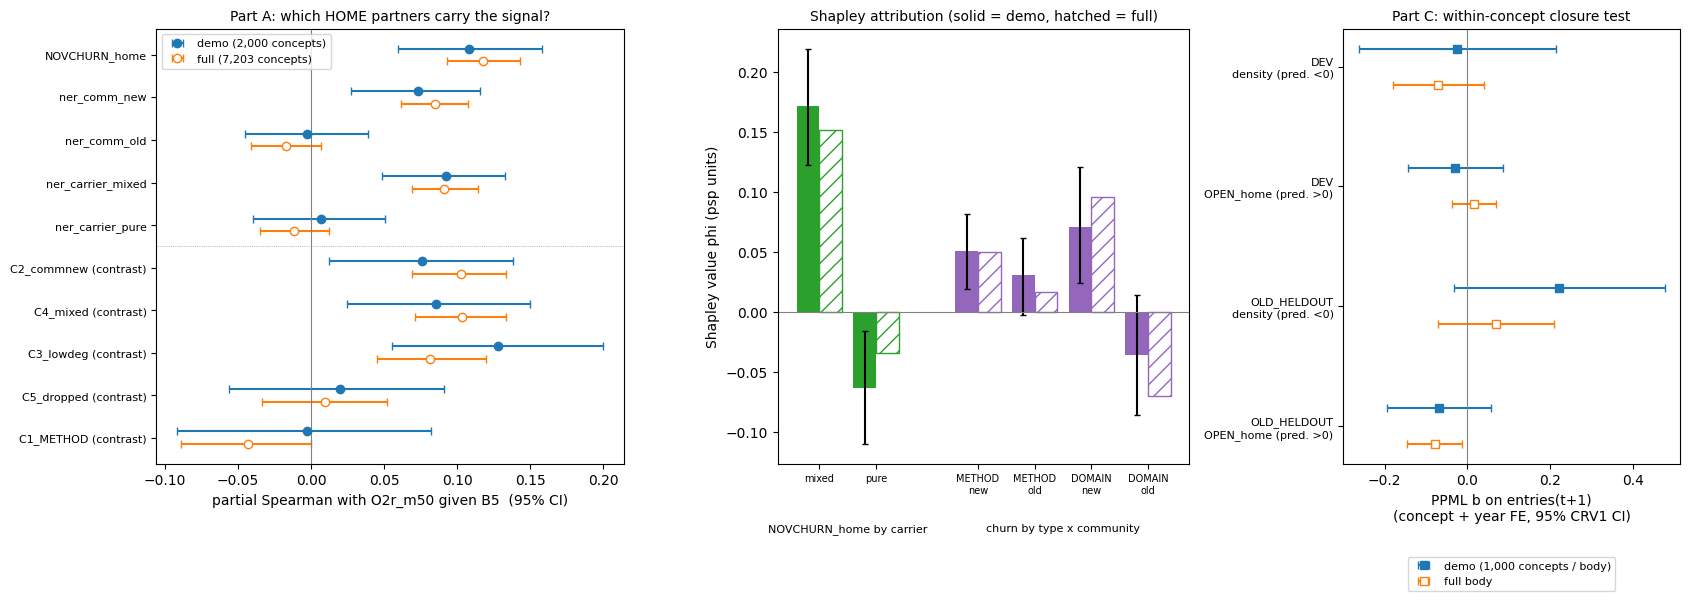

Summary on the demo subset (N_BOOT=2000):
  * C2 new- minus old-community partners (new_edge_rate): +0.076 [+0.013, +0.138], Holm p 0.0585 | full +0.102 [+0.069, +0.133], Holm p 0.0025
  * C4 mixed- minus pure-carrier partners (new_edge_rate): +0.085 [+0.025, +0.150], Holm p 0.0380 | full +0.103 [+0.071, +0.134], Holm p 0.0025
    Both point the same way as the full data. With 2,000 of 7,203 concepts the CIs are about twice as wide,
    so Holm-adjusted p-values on the subset are larger than the full-data 0.0025.
  * Controlling for the bridging-paper share cuts NOVCHURN's psp +0.108 -> +0.067 (full 0.118 -> 0.056).
  * Closure test on DEV: density b -0.025 [-0.263, +0.213], OPEN_home b -0.029 [-0.144, +0.085]. CIs include 0: True (full data: both null).


In [13]:
fig, axs = plt.subplots(1, 3, figsize=(17, 6.2), gridspec_kw={"width_ratios": [1.25, 1.1, 0.9]})

# (a) class parts + Holm contrasts
rows = [("NOVCHURN_home", "c"), ("ner_comm_new", "c"), ("ner_comm_old", "c"), ("ner_carrier_mixed", "c"),
        ("ner_carrier_pure", "c"), ("C2_commnew_minus_commold_ner", "h"), ("C4_mixed_minus_pure_ner", "h"),
        ("C3_lowdeg_minus_highdeg_nov", "h"), ("C5_dropped_minus_added_churn", "h"), ("C1_METHOD_minus_DOMAIN_novnull", "h")]
a = axs[0]
for i, (nm, kind) in enumerate(rows):
    if kind == "c":
        e, r = RA["components"][nm], ra["components"][nm]
        pe, pr = e["rho"], r["rho"]
    else:
        e, r = H[nm], ra["holm_contrasts"][nm]
        pe, pr = e["diff"], r["diff"]
    a.errorbar(pe, i - 0.15, xerr=[[pe - e["ci"][0]], [e["ci"][1] - pe]], fmt="o", color="C0", capsize=3,
               label="demo (2,000 concepts)" if i == 0 else None)
    a.errorbar(pr, i + 0.15, xerr=[[pr - r["ci"][0]], [r["ci"][1] - pr]], fmt="o", mfc="white", color="C1",
               capsize=3, label=f"full ({ra['n_base']:,} concepts)" if i == 0 else None)
a.axvline(0, color="grey", lw=0.8)
a.axhline(4.5, color="grey", lw=0.5, ls=":")
a.set_yticks(range(len(rows)))
a.set_yticklabels([n.split("_minus")[0] + (" (contrast)" if k_ == "h" else "") for n, k_ in rows], fontsize=8)
a.invert_yaxis()
a.set_xlabel("partial Spearman with O2r_m50 given B5  (95% CI)")
a.set_title("Part A: which HOME partners carry the signal?", fontsize=10)
a.legend(fontsize=8, loc="upper left")

# (b) Shapley games
a = axs[1]
xt, lab = [], []
x0 = 0
for g, c in (("NOVCHURN_carrier", "C2"), ("churn_type_x_comm", "C4")):
    S, r = RA["shapley"][g], ra["shapley"][g]
    for j, p in enumerate(S["players"]):
        ph = S["phi"][p]
        lo, hi = ph.get("phi_ci", [ph["phi"]] * 2)
        a.bar(x0 + j - 0.2, ph["phi"], 0.4, color=c, yerr=[[ph["phi"] - lo], [hi - ph["phi"]]], capsize=2)
        a.bar(x0 + j + 0.2, r["phi"][p], 0.4, color="white", edgecolor=c, hatch="//")
        xt.append(x0 + j); lab.append(p.replace("_", "\n"))
    a.text(x0 + (len(S["players"]) - 1) / 2, -0.155, "NOVCHURN_home by carrier" if g == "NOVCHURN_carrier"
           else "churn by type x community", ha="center", fontsize=8, transform=a.get_xaxis_transform())
    x0 += len(S["players"]) + 0.8
a.axhline(0, color="grey", lw=0.8)
a.set_xticks(xt); a.set_xticklabels(lab, fontsize=7)
a.set_ylabel("Shapley value phi (psp units)")
a.set_title("Shapley attribution (solid = demo, hatched = full)", fontsize=10)

# (c) PPML coefficients
a = axs[2]
items = [(b, hk) for b in ("DEV", "OLD_HELDOUT") for hk in ("H_M1_density", "H_M2_OPEN_home")]
for i, (b, hk) in enumerate(items):
    e, r = RC[b][hk], rc[b][hk]
    a.errorbar(e["b"], i - 0.15, xerr=[[e["b"] - e["ci"][0]], [e["ci"][1] - e["b"]]], fmt="s", color="C0",
               capsize=3, label="demo (1,000 concepts / body)" if i == 0 else None)
    a.errorbar(r["b"], i + 0.15, xerr=[[r["b"] - r["ci_crv1"][0]], [r["ci_crv1"][1] - r["b"]]], fmt="s",
               mfc="white", color="C1", capsize=3, label="full body" if i == 0 else None)
a.axvline(0, color="grey", lw=0.8)
a.set_yticks(range(len(items)))
a.set_yticklabels([f"{b}\n{'density (pred. <0)' if 'density' in hk else 'OPEN_home (pred. >0)'}" for b, hk in items],
                  fontsize=8)
a.invert_yaxis()
a.set_xlabel("PPML b on entries(t+1)\n(concept + year FE, 95% CRV1 CI)")
a.set_title("Part C: within-concept closure test", fontsize=10)
a.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=1)
fig.tight_layout()
plt.show()

c2, c4 = H["C2_commnew_minus_commold_ner"], H["C4_mixed_minus_pure_ner"]
nb = BR["NOVCHURN_home|B5"]["rho"], BR["NOVCHURN_home|B5+bridging_share_home"]["rho"]
print(f"Summary on the demo subset (N_BOOT={N_BOOT}):")
rf = ra["holm_contrasts"]
print(f"  * C2 new- minus old-community partners (new_edge_rate): {fmtd(c2)}, Holm p {c2['p_holm']:.4f} "
      f"| full {fmtd(rf['C2_commnew_minus_commold_ner'])}, Holm p {rf['C2_commnew_minus_commold_ner']['p_holm']:.4f}")
print(f"  * C4 mixed- minus pure-carrier partners (new_edge_rate): {fmtd(c4)}, Holm p {c4['p_holm']:.4f} "
      f"| full {fmtd(rf['C4_mixed_minus_pure_ner'])}, Holm p {rf['C4_mixed_minus_pure_ner']['p_holm']:.4f}")
print("    Both point the same way as the full data. With 2,000 of 7,203 concepts the CIs are about twice as wide,")
print("    so Holm-adjusted p-values on the subset are larger than the full-data 0.0025.")
print(f"  * Controlling for the bridging-paper share cuts NOVCHURN's psp {nb[0]:+.3f} -> {nb[1]:+.3f} (full 0.118 -> 0.056).")
d, o = RC["DEV"]["H_M1_density"], RC["DEV"]["H_M2_OPEN_home"]
print(f"  * Closure test on DEV: density b {fmtb(d)}, OPEN_home b {fmtb(o)}. "
      f"CIs include 0: {d['ci'][0] < 0 < d['ci'][1] and o['ci'][0] < 0 < o['ci'][1]} (full data: both null).")